In [ ]:
import pandas as pd
import matplotlib as plt
import seaborn

#phase 1 -- DATA COLLECTION AND UNDERSTANDING
df=pd.read_csv('ecommerce_customer_dataset.csv')
df_head=df.head()
df_info=df.info()
df_desc=df.describe()
df_shape=df.shape
df_column=df.columns
print(df_head,df_info,df_desc,df_shape,df_column)

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       300 non-null    str    
 1   age               300 non-null    int64  
 2   gender            300 non-null    str    
 3   annual_income_k$  300 non-null    int64  
 4   spending_score    300 non-null    float64
dtypes: float64(1), int64(2), str(2)
memory usage: 11.8 KB
  customer_id  age  gender  annual_income_k$  spending_score
0       C0001   58  Female                71            38.5
1       C0002   25  Female               139            86.0
2       C0003   19    Male                71            37.6
3       C0004   65    Male                84            63.0
4       C0005   35    Male               126            74.3 None              age  annual_income_k$  spending_score
count  300.00000         300.00000      300.000000
mean    43.41000          83.69000       51.38

In [ ]:
# phase 2 -- DATA CLEANING
null_values=df.isnull().sum()
duplicate_values=df.duplicated().sum()
print(f"Number of null values:-\n{null_values}\n\nNumber of duplicates:-{duplicate_values}")
df.rename(columns={"annual_income_k$":"annual_income"},inplace=True)
df.drop("customer_id",axis=1,inplace=True)



Number of null values:-
customer_id         0
age                 0
gender              0
annual_income_k$    0
spending_score      0
dtype: int64

Number of duplicates:-0


In [ ]:
# phase 3 -- FEATURE ENGINEERING
def age_decision(row):
    age=row['age']
    if 0 <= age <= 25:
        return "Young"
    elif 26 <= age <= 40:
        return "Adult"
    elif 41 <= age <= 60:
        return "Middle Age"
    else:
        return "Senior"
df['age_group']=df.apply(age_decision,axis=1)

                         

In [13]:
low_max = df['annual_income'].mean()
medium_max = df['annual_income'].mean() + (df['annual_income'].max() - df['annual_income'].mean()) / 2

def income_cat(row):
    income = row['annual_income']
    if income <= low_max:
        return 'Low'
    elif income <= medium_max:
        return 'Medium'
    else:
        return 'High'

df['income_category'] = df.apply(income_cat, axis=1)   


In [14]:
mean_spending = df['spending_score'].mean()
max_spending = df['spending_score'].max()

medium_threshold = (mean_spending + max_spending) / 2

def spending_category(row):
    score = row['spending_score']
    if score <= mean_spending:
        return 'Low'
    elif score <= medium_threshold:
        return 'Medium'
    else:
        return 'High spender'

df['spending_category'] = df.apply(spending_category, axis=1)   
print(df)

     age  gender  annual_income  spending_score   age_group income_category  \
0     58  Female             71            38.5  Middle Age             Low   
1     25  Female            139            86.0       Young            High   
2     19    Male             71            37.6       Young             Low   
3     65    Male             84            63.0      Senior          Medium   
4     35    Male            126            74.3       Adult            High   
..   ...     ...            ...             ...         ...             ...   
295   24    Male             28            16.9       Young             Low   
296   60  Female             67            22.0  Middle Age             Low   
297   45  Female             83            54.0  Middle Age             Low   
298   40  Female             48            19.8       Adult             Low   
299   45  Female             88            42.7  Middle Age          Medium   

    spending_category  
0                 Low  
1  

In [15]:
df.to_csv('ecommerce_customer_dataset.csv', index=False)   

In [ ]:
# phase 4 -- DATA ANALYSIS
avg_spending=df.groupby('gender')['spending_score'].mean()
avg_income=df.groupby('gender')['annual_income'].mean()
print(f"average spending score by {avg_spending}:")
print(f"average income by {avg_income}:")
''' The male's spends more and the female's earn more '''

average spending score by gender
Female    50.850
Male      51.918
Name: spending_score, dtype: float64:
average income by gender
Female    84.16
Male      83.22
Name: annual_income, dtype: float64:


" The male's spends more and the female's earn more "

In [47]:
avg_spending_per_age = df.groupby('age')['spending_score'].mean()
result = avg_spending_per_age[avg_spending_per_age == avg_spending_per_age.max()]

count_customer_PerAge=df.groupby('age')['age'].count()
result1= count_customer_PerAge[count_customer_PerAge == count_customer_PerAge.max()]
print(f"The age group that spends most and how much is {result}")
print(f"The age group which has more customer is {result1}")


The age group that spends most and how much is age
36    74.533333
Name: spending_score, dtype: float64
The age group which has more customer is age
32    12
Name: age, dtype: int64


In [48]:
avg_spending_category=df.groupby('income_category')['spending_score'].mean()
print(avg_spending_category)
''' The high income customers always spend more '''

income_category
High      71.281707
Low       37.244218
Medium    57.678873
Name: spending_score, dtype: float64


' The high income customers always spend more '

In [63]:
top_10_by_spending_score = df.sort_values(by='spending_score', ascending=False)
print("The top ten customers by spending score are of age and income as below")
print(top_10_by_spending_score[['age', 'annual_income','spending_score']].head(10))   

The top ten customers by spending score are of age and income as below
     age  annual_income  spending_score
89    31            134            94.2
182   36            140            93.9
78    23            140            93.2
294   24            128            90.4
88    40            138            90.0
134   34            123            88.7
151   23            149            87.5
19    31            133            87.3
285   54            146            86.9
105   35            139            86.8


In [59]:
bottom_10_by_spending_score = df.sort_values(by='spending_score', ascending=True).head(10)
print("Bottom 10 customers by spending score:")
print(bottom_10_by_spending_score[['age', 'annual_income', 'spending_score']])   

Bottom 10 customers by spending score:
     age  annual_income  spending_score
112   67             17             2.4
289   68             28             3.2
250   59             21             5.7
35    69             19             8.8
205   52             35            10.9
163   42             26            11.4
142   55             45            13.5
216   37             23            13.5
190   50             45            13.6
200   30             30            14.0


In [68]:
def segment_customer(row):
    if row["income_category"] == "High" and row["spending_category"] == "High":
        return "Premium"
    
    elif row["income_category"] == "High" and row["spending_category"] == "Low":
        return "Careful"
    
    elif row["income_category"] == "Low" and row["spending_category"] == "High":
        return "Risky"
    
    elif row["income_category"] == "Low" and row["spending_category"] == "Low":
        return "Budget"
    
    else:
        return "Average"
df["customer_segment"] = df.apply(segment_customer,axis=1)
    
print(df)
df.to_csv('ecommerce_customer_dataset.csv', index=False)   

     age  gender  annual_income  spending_score   age_group income_category  \
0     58  Female             71            38.5  Middle Age             Low   
1     25  Female            139            86.0       Young            High   
2     19    Male             71            37.6       Young             Low   
3     65    Male             84            63.0      Senior          Medium   
4     35    Male            126            74.3       Adult            High   
..   ...     ...            ...             ...         ...             ...   
295   24    Male             28            16.9       Young             Low   
296   60  Female             67            22.0  Middle Age             Low   
297   45  Female             83            54.0  Middle Age             Low   
298   40  Female             48            19.8       Adult             Low   
299   45  Female             88            42.7  Middle Age          Medium   

    spending_category customer_segment  
0         

In [69]:
df.groupby("customer_segment")["spending_score"].mean()

customer_segment
Average    64.121910
Budget     32.165812
Careful    47.620000
Name: spending_score, dtype: float64

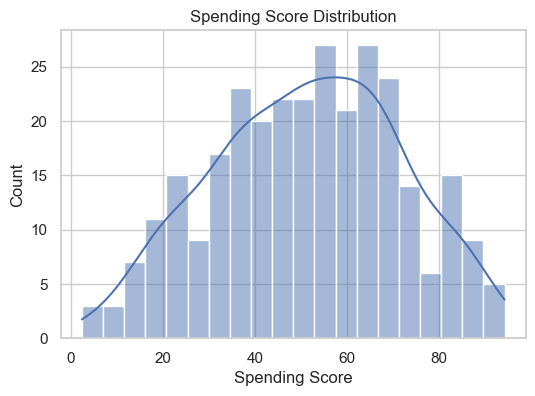

In [ ]:
#phase 5 -- VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

# SPENDING SCORE DISTRIBUTION
plt.figure(figsize=(6,4))
sns.histplot(df["spending_score"], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Count")
plt.show()


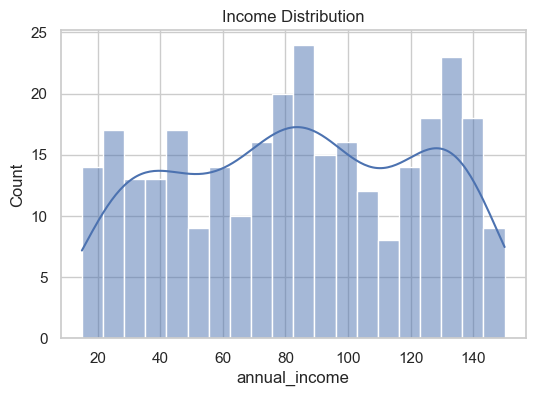

In [88]:
# INCOME DISTRIBUTION
plt.figure(figsize=(6,4))
sns.histplot(df["annual_income"], bins=20, kde=True)
plt.title("Income Distribution")
plt.show()

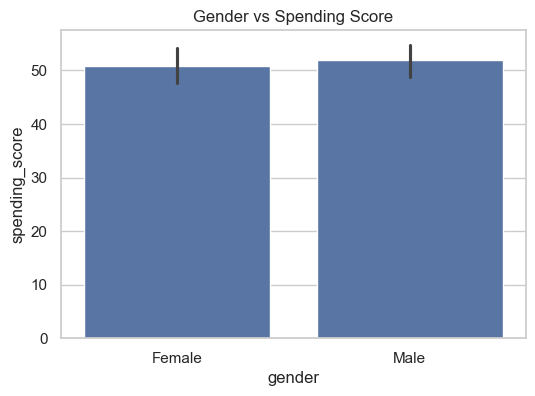

In [90]:
# GENDER VS SPENDING
plt.figure(figsize=(6,4))
sns.barplot(x="gender", y="spending_score", data=df)
plt.title("Gender vs Spending Score")
plt.show()

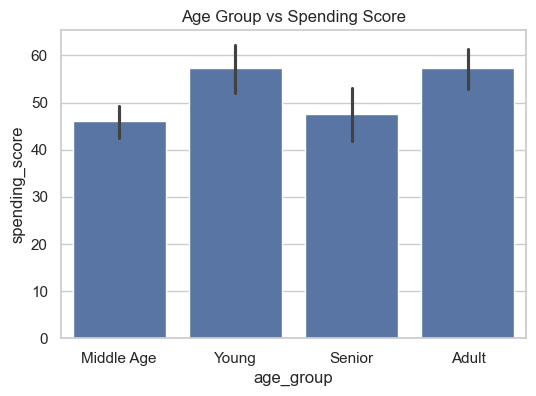

In [91]:
# AGE GROUP VS SPENDING
plt.figure(figsize=(6,4))
sns.barplot(x="age_group", y="spending_score", data=df)
plt.title("Age Group vs Spending Score")
plt.show()

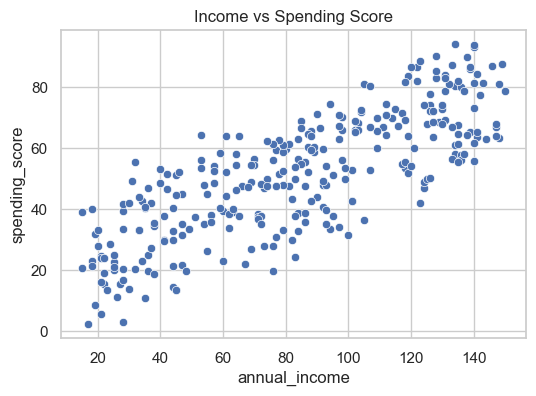

In [92]:
# INCOME VS SPENDING
plt.figure(figsize=(6,4))
sns.scatterplot(x="annual_income", y="spending_score", data=df)
plt.title("Income vs Spending Score")
plt.show()

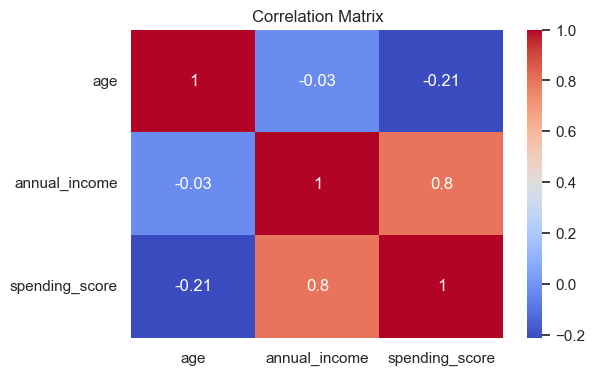

In [93]:
# CORRELATION HEATMAP
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

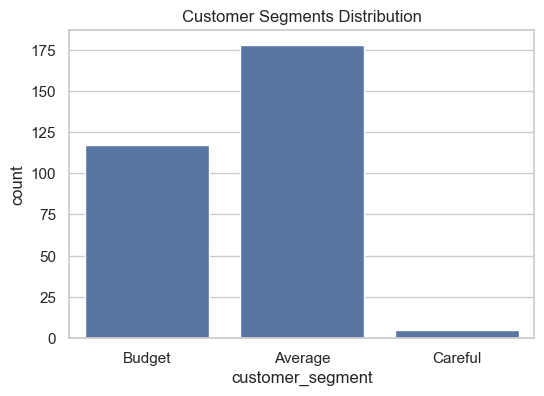

In [94]:
# CUSTOMER SEGMENT COUNT
plt.figure(figsize=(6,4))
sns.countplot(x="customer_segment", data=df)
plt.title("Customer Segments Distribution")
plt.show()

In [95]:
# SAVE PLOTS
plt.figure(figsize=(6,4))
sns.histplot(df["spending_score"], bins=20)
plt.savefig("images/spending_distribution.png")
plt.close()